# SciPy Bootcamp — W2, Day D3E
```
##### Multiple testing, Simpson's Paradox, novelty effect, Bayesian AB
##### multipletests, Bayesian posterior, SRM detection
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — Multiple testing in practice
##### Q2 — Simpson's Paradox hands-on
##### Q3 — Novelty effect analysis
##### Q4 — Bayesian A/B test dashboard
##### Q5 — Full experiment audit


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Multiple testing in practice

```
# Simulate 20 A/B tests: 15 null (no effect), 5 with true effects.
# (a) Plot raw p-values as a sorted dot plot (volcano plot style).
#     Color: red=truly null, green=truly has effect. Add alpha=0.05 line.
# (b) Apply Bonferroni and BH FDR corrections. 
#     Plot 3 side-by-side panels: uncorrected, Bonferroni, BH FDR.
#     Show which tests are flagged in each.
# (c) Compute: true positives, false positives, false negatives for each method.
# (d) Which method would you use if running 20 feature tests simultaneously? Why?
```


In [7]:
# (a) Plot raw p-values as a sorted dot plot (volcano plot style).
#     Color: red=truly null, green=truly has effect. Add alpha=0.05 line.

# setup data
np.random.seed(420)

null_pvals = np.random.uniform(0,1,15) # no effect
print(null_pvals)

effect_pvals = np.random.beta(1,8,5) # with effect
print(effect_pvals)

df = pd.DataFrame({
    'p_value': np.concatenate([null_pvals, effect_pvals]),
    'True_Effect': ['Truly Null (No Effect)'] * 15 + ['Truly Has Effect'] * 5
})

# Sort them exactly as requested in part (a)
df = df.sort_values(by='p_value').reset_index(drop=True)
df['Sorted Rank'] = df.index + 1
print(df)

[0.31564591 0.45303068 0.26698226 0.10892818 0.86816648 0.62972852
 0.35251871 0.0675376  0.62635059 0.59866086 0.09221725 0.05685155
 0.2371322  0.23540367 0.77437138]
[0.00668513 0.3901331  0.03658446 0.0703601  0.02393227]
     p_value             True_Effect  Sorted Rank
0   0.006685        Truly Has Effect            1
1   0.023932        Truly Has Effect            2
2   0.036584        Truly Has Effect            3
3   0.056852  Truly Null (No Effect)            4
4   0.067538  Truly Null (No Effect)            5
5   0.070360        Truly Has Effect            6
6   0.092217  Truly Null (No Effect)            7
7   0.108928  Truly Null (No Effect)            8
8   0.235404  Truly Null (No Effect)            9
9   0.237132  Truly Null (No Effect)           10
10  0.266982  Truly Null (No Effect)           11
11  0.315646  Truly Null (No Effect)           12
12  0.352519  Truly Null (No Effect)           13
13  0.390133        Truly Has Effect           14
14  0.453031  Truly Null

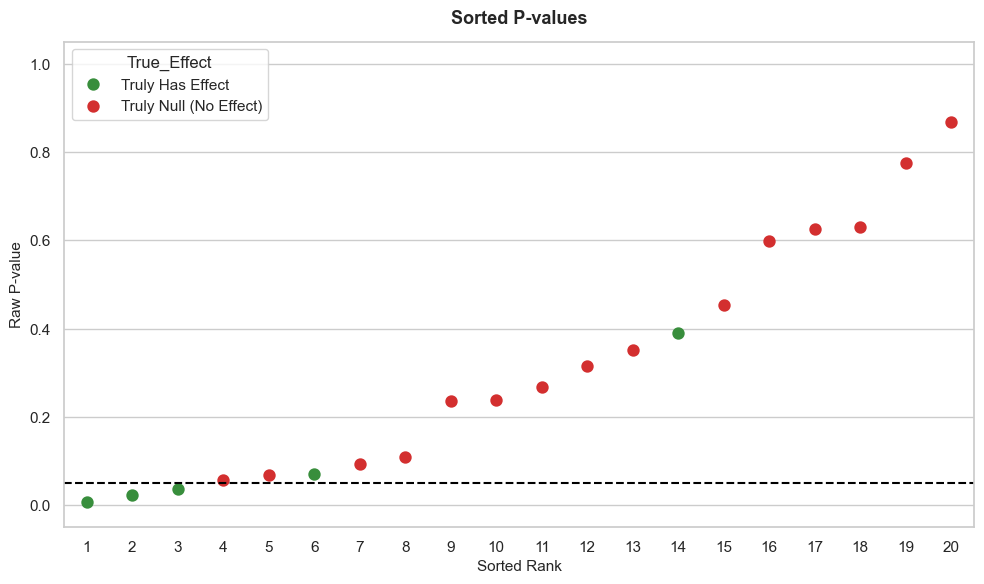

In [ ]:
plt.figure(figsize=(10,6))

sns.pointplot(
    data=df,
    x='Sorted Rank',
    y='p_value',
    hue='True_Effect',
    palette={'Truly Null (No Effect)': '#D32F2F', 'Truly Has Effect': '#388E3C'},
    join=False,       # ✅ Crucial: Prevents drawing a line connecting the dots
    errorbar=None,    # ✅ Crucial: Stops Seaborn from calculating group error bars
    markers='o',      # Formats points as circles
    scale=1.2         # Increases point size for visual scannability
)

plt.axhline(y=0.05, color='black', linestyle='--', linewidth=1.5, label='Alpha = 0.05')
plt.title('Sorted P-values', fontweight='bold', fontsize=13, y=1.02)
plt.xlabel('Sorted Rank', fontsize=11)
plt.ylabel('Raw P-value', fontsize=11)
plt.ylim(-0.05, 1.05)

sns.move_legend(plt.gca(), loc="upper left", frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

After Bonferroni: 0 significant
After BH FDR:     0 significant


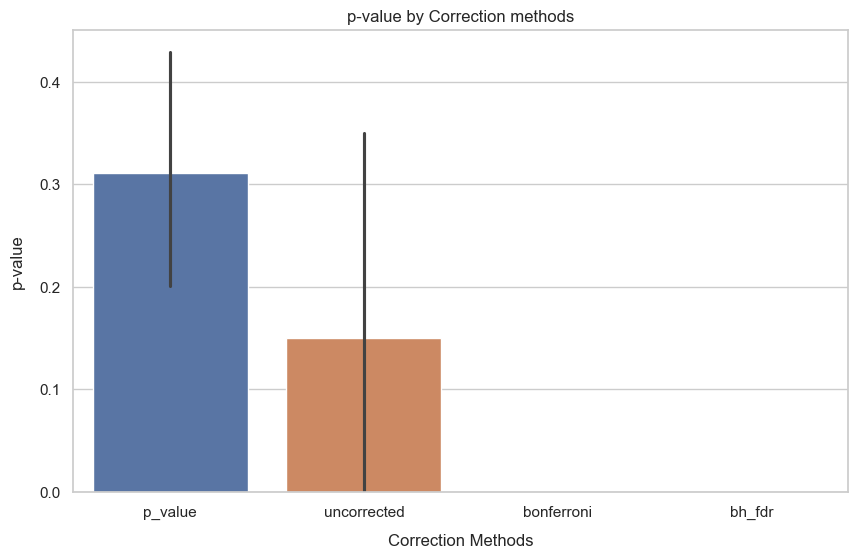

In [13]:
# (b) Apply Bonferroni and BH FDR corrections. 
#     Plot 3 side-by-side panels: uncorrected, Bonferroni, BH FDR.
#     Show which tests are flagged in each.

# Bonferroni

from statsmodels.stats.multitest import multipletests

reject_bonf, p_bonf, _, _ = multipletests(df['p_value'], alpha=0.05, method='bonferroni')
print(f'After Bonferroni: {sum(reject_bonf)} significant')

# BH DFR
reject_bh, p_bh, _, _ = multipletests(df['p_value'], alpha=0.05, method='fdr_bh')
print(f'After BH FDR:     {sum(reject_bh)} significant')

# Show which tests each method flags
results = pd.DataFrame({'p_value': df['p_value'],
                        'uncorrected': df['p_value'] < 0.05,
                        'bonferroni': reject_bonf,
                        'bh_fdr': reject_bh})

results

plt.figure(figsize=(10,6))
sns.barplot(results)
plt.xlabel('Correction Methods', labelpad=10)
plt.ylabel('p-value', labelpad=10)
plt.title('p-value by Correction methods')
plt.show()
#results.sort_values('p_value').plot(kind='bar', y=['uncorrected','bonferroni','bh_fdr'])


In [15]:
# (c) Compute: true positives, false positives, false negatives for each method.

df_combo = pd.DataFrame({
    'Is_Real': np.array([False] * 15 + [True] * 5),
    'Uncorrected': df['p_value'] < 0.05,
    'Bonferroni': reject_bonf,
    'BH_FDR': reject_bh
})

for col in ['Uncorrected', 'Bonferroni', 'BH_FDR']:
    tp = len(df_combo[(df_combo['Is_Real'] == True) & (df_combo[col] == True)])
    fp = len(df_combo[(df_combo['Is_Real'] == False) & (df_combo[col] == True)])
    fn = len(df_combo[(df_combo['Is_Real'] == True) & (df_combo[col] == False)])
    
    print(f"{col:<12} | TP: {tp} | FP: {fp} | FN: {fn}")

Uncorrected  | TP: 0 | FP: 3 | FN: 5
Bonferroni   | TP: 0 | FP: 0 | FN: 5
BH_FDR       | TP: 0 | FP: 0 | FN: 5


```
# (d) Which method would you use if running 20 feature tests simultaneously? Why?

In this simulation both corrections returned zero significant results, illustrating how correction is conservative at n=20. 
BH FDR would outperform Bonferroni at larger scale where real effects have smaller p-values

---

### Q2 — Simpson's Paradox hands-on

```
# Build the Simpson's Paradox dataset from the theory (Day 3E):
# Control: 8000 mobile (8% conv) + 2000 desktop (25% conv)
# Treatment: 2000 mobile (8% conv) + 8000 desktop (25% conv)
# (a) Compute overall conversion for each group. Plot as bar chart.
# (b) Compute conversion by segment. Plot as grouped bar chart.
# (c) Build a stacked bar chart showing traffic composition (mobile/desktop split).
# (d) In a markdown cell: write the analysis you would submit in a real post-experiment report,
#     including both the flawed aggregated conclusion and the correct segmented conclusion.
```


In [ ]:
# (a) Compute overall conversion for each group. Plot as bar chart.

data_simpson = pd.DataFrame({
    'group'    : ['Control','Control','Treatment','Treatment'],
    'segment'  : ['Mobile', 'Desktop', 'Mobile', 'Desktop'],
    'users'    : [8000, 2000, 2000, 8000],
    'converted': [640,  500,  160,  2000],
})

data_simpson['rate'] = data_simpson['converted'] / data_simpson['users']

display(data_simpson)

plt.figure(figsize=(8,6))


sns.barplot(data=df, x='category_column', y='value_column')

plt.title("The Paradox: Imbalanced Segments Mimic a 'Win'", fontsize=14)
plt.ylabel("Proportion of Users")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()
plt.show()

,group,segment,users,converted,rate
0,Control,Mobile,8000,640,0.08
1,Control,Desktop,2000,500,0.25
2,Treatment,Mobile,2000,160,0.08
3,Treatment,Desktop,8000,2000,0.25


In [21]:
# Compute overall aggregated conversions by group
overall = data_simpson.groupby('group', as_index=False)[['users', 'converted']].sum()
overall['overall_rate'] = overall['converted'] / overall['users']
overall['overall_rate_pct'] = overall['overall_rate'] * 100
print(overall.to_string(index=False))

    group  users  converted  overall_rate  overall_rate_pct
  Control  10000       1140         0.114              11.4
Treatment  10000       2160         0.216              21.6


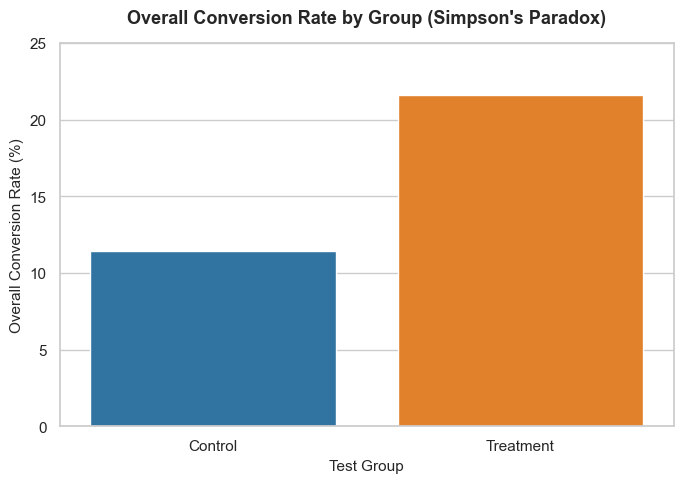

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=overall,
    x='group',
    y='overall_rate_pct',
    hue='group',
    palette={'Control': '#1F77B4', 'Treatment': '#FF7F0E'},
    legend=False
)

plt.title("Overall Conversion Rate by Group (Simpson's Paradox)", fontweight='bold', fontsize=13, y=1.03)
plt.xlabel("Test Group", fontsize=11)
plt.ylabel("Overall Conversion Rate (%)", fontsize=11)
plt.ylim(0, 25)

plt.tight_layout()
plt.show()

segment  users  converted  overall_rate  segment_rate_pct
Desktop  10000       2500          0.25              25.0
 Mobile  10000        800          0.08               8.0


(0.0, 30.0)

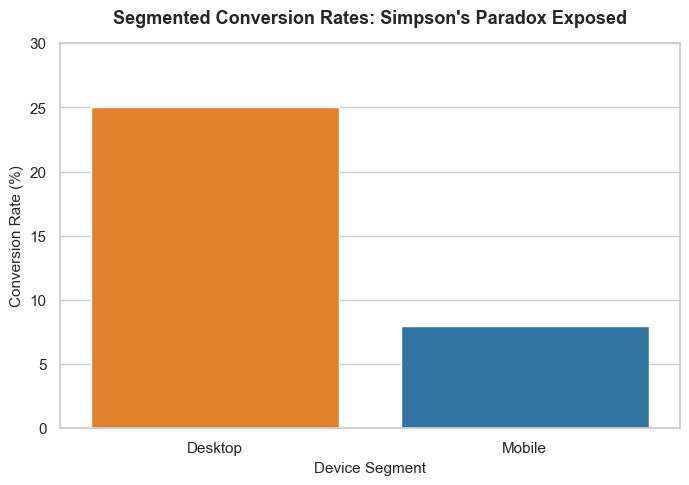

In [23]:
# (b) Compute conversion by segment. Plot as grouped bar chart.

overall_segment = data_simpson.groupby('segment', as_index=False)[['users', 'converted']].sum()
overall_segment['overall_rate'] = overall_segment['converted'] / overall_segment['users']
overall_segment['segment_rate_pct'] = overall_segment['overall_rate'] * 100
print(overall_segment.to_string(index=False))


plt.figure(figsize=(8, 5))

sns.barplot(
    data=overall_segment,
    x='segment',
    y='segment_rate_pct',
    hue='segment',
    palette={'Mobile': '#1F77B4', 'Desktop': '#FF7F0E'}
)

# Customize chart presentation
plt.title("Segmented Conversion Rates: Simpson's Paradox Exposed", fontweight='bold', fontsize=13, y=1.03)
plt.xlabel("Device Segment", fontsize=11)
plt.ylabel("Conversion Rate (%)", fontsize=11)
plt.ylim(0, 30)

In [ ]:
# (c) Build a stacked bar chart showing traffic composition (mobile/desktop split).

totals = data_simpson.pivot(index='group', columns='segment', values='users')
totals['Total'] = totals['Desktop'] + totals['Mobile']
totals = totals.reset_index()

print(totals.to_string(index=False))

    group  Desktop  Mobile  Total
  Control     2000    8000  10000
Treatment     8000    2000  10000


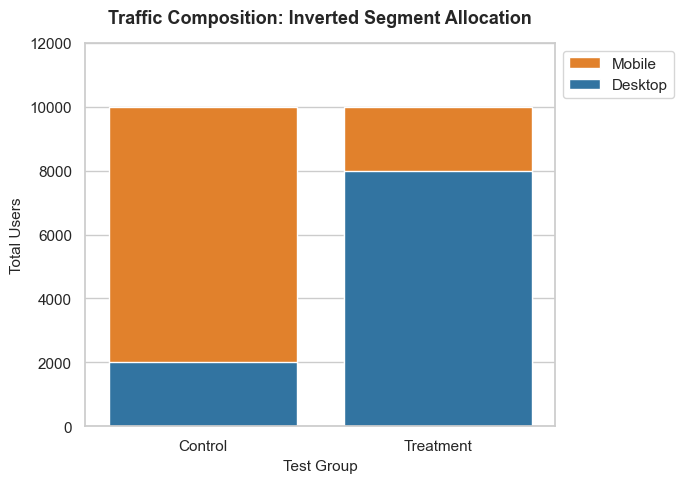

In [ ]:
plt.figure(figsize=(7, 5))

# Step A: Draw the full total height bar (Mobile + Desktop stacked combined)
sns.barplot(
    data=totals, 
    x='group', 
    y='Total', 
    color='#FF7F0E', # Orange representing Mobile
    label='Mobile'
)

# Step B: Overlap the bottom portion with just the Desktop user count
sns.barplot(
    data=totals, 
    x='group', 
    y='Desktop', 
    color='#1F77B4', # Blue representing Desktop
    label='Desktop'
)

plt.title("Traffic Composition: Inverted Segment Allocation", fontweight='bold', fontsize=13, y=1.03)
plt.xlabel("Test Group", fontsize=11)
plt.ylabel("Total Users", fontsize=11)
plt.ylim(0, 12000)


plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

```
# (d) In a markdown cell: write the analysis you would submit in a real post-experiment report,
#     including both the flawed aggregated conclusion and the correct segmented conclusion.plt.show()

An aggregated review incorrectly suggested a massive conversion surge, but breaking down performance by device reveals identical 8% mobile and 25% desktop rates for both variants. 
This deceptive result is a classic example of Simpson's Paradox, triggered because the randomization pipeline failed to distribute traffic evenly across environments. 
The treatment group was artificially inflated, being heavily weighted with high-converting desktop users, while the control group was composed mostly of low-converting mobile users. 
Because the new variant provides a 0% net performance impact within segments, a hard reject on rolling out the treatment is recommended.

---

### Q3 — Novelty effect analysis

```
# Simulate 28 days of an A/B test:
# Week 1: treatment CTR = 14% (novelty spike), control = 9%
# Week 2: treatment CTR = 11.5% (decay), control = 9%  
# Week 3-4: treatment CTR = 9.5% (settled), control = 9%
# (a) Plot daily CTR for both groups with 7-day rolling average overlaid.
# (b) Run t-tests on: week 1 only, week 4 only, all 4 weeks.
#     Print p-values and conclusions from each window.
# (c) If you had stopped after week 1 — what decision would you have made?
# (d) What is the correct minimum run time for this experiment?
```


In [ ]:
# (a) Plot daily CTR for both groups with 7-day rolling average overlaid.

np.random.seed(420)
daily_n = 500
days = 28
ctrs = ([0.14]*7 + [0.115]*7 + [0.095]*7 + [0.095]*7)  # treatment
ctrl_ctr = [0.09]*28

daily_ctrl = np.random.binomial(daily_n, ctrl_ctr) / daily_n
daily_trt  = np.random.binomial(daily_n, ctrs) / daily_n

df_daily = pd.DataFrame({'Day': range(1,29),
                         'Control': daily_ctrl,
                         'Treatment': daily_trt})

# Add 7-day rolling average
df_daily['ctrl_roll'] = df_daily['Control'].rolling(7).mean()
df_daily['trt_roll']  = df_daily['Treatment'].rolling(7).mean()
print(df_daily)

    Day  Control  Treatment  ctrl_roll  trt_roll
0     1    0.096      0.132        NaN       NaN
1     2    0.100      0.142        NaN       NaN
2     3    0.068      0.150        NaN       NaN
3     4    0.104      0.146        NaN       NaN
4     5    0.094      0.170        NaN       NaN
5     6    0.096      0.148        NaN       NaN
6     7    0.104      0.160   0.094571  0.149714
7     8    0.098      0.138   0.094857  0.150571
8     9    0.106      0.102   0.095714  0.144857
9    10    0.104      0.122   0.100857  0.140857
10   11    0.088      0.124   0.098571  0.137714
11   12    0.094      0.108   0.098571  0.128857
12   13    0.072      0.118   0.095143  0.124571
13   14    0.092      0.112   0.093429  0.117714
14   15    0.112      0.098   0.095429  0.112000
15   16    0.084      0.092   0.092286  0.110571
16   17    0.096      0.090   0.091143  0.106000
17   18    0.078      0.090   0.089714  0.101143
18   19    0.096      0.094   0.090000  0.099143
19   20    0.098    

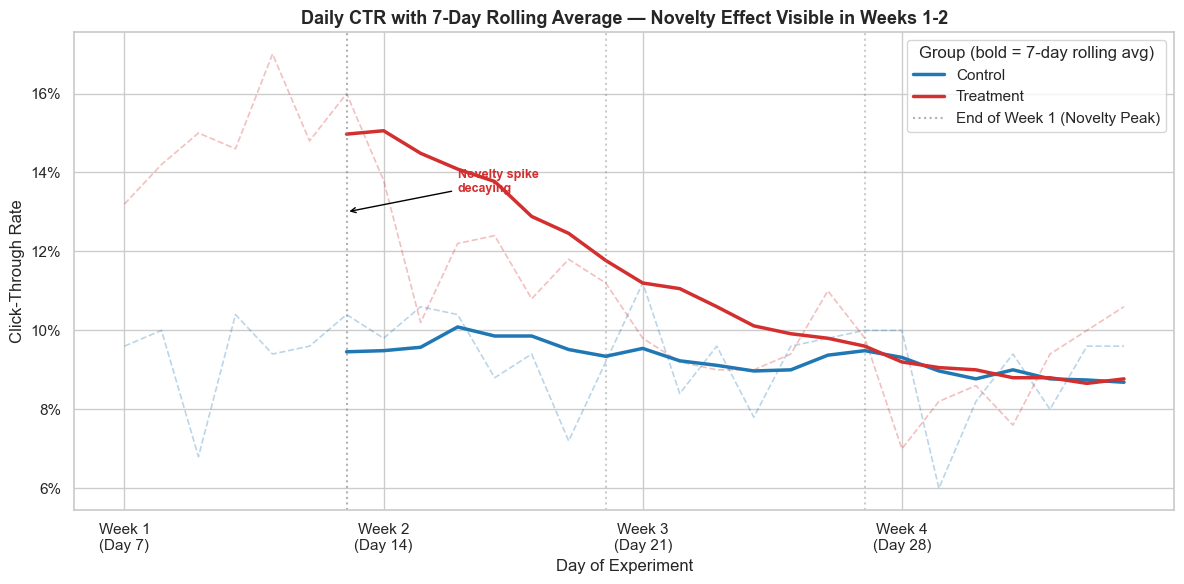

In [57]:
# Melt to long format for seaborn
df_long = df_daily.melt(id_vars='Day', 
                         value_vars=['Control', 'Treatment'],
                         var_name='Group', value_name='Daily_CTR')

df_roll = df_daily.melt(id_vars='Day',
                         value_vars=['ctrl_roll', 'trt_roll'],
                         var_name='Group', value_name='Rolling_CTR')
df_roll['Group'] = df_roll['Group'].map({'ctrl_roll': 'Control', 
                                          'trt_roll': 'Treatment'})

palette = {'Control': '#1F77B4', 'Treatment': '#D32F2F'}

plt.figure(figsize=(12, 6))

# Daily raw CTR — light, faded lines
sns.lineplot(data=df_long, x='Day', y='Daily_CTR',
             hue='Group', palette=palette,
             alpha=0.3, linewidth=1.2, linestyle='--', legend=False)

# 7-day rolling average — bold, primary lines
sns.lineplot(data=df_roll, x='Day', y='Rolling_CTR',
             hue='Group', palette=palette,
             linewidth=2.5)

# Novelty peak annotation
plt.axvline(7, color='grey', linestyle=':', alpha=0.6, label='End of Week 1 (Novelty Peak)')
plt.axvline(14, color='grey', linestyle=':', alpha=0.4)
plt.axvline(21, color='grey', linestyle=':', alpha=0.4)

plt.annotate('Novelty spike\ndecaying', xy=(7, 0.13), xytext=(10, 0.135),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='#D32F2F', fontweight='bold')

plt.title('Daily CTR with 7-Day Rolling Average — Novelty Effect Visible in Weeks 1-2',
          fontweight='bold', fontsize=13)
plt.xlabel('Day of Experiment')
plt.ylabel('Click-Through Rate')
plt.gca().yaxis.set_major_formatter('{:.0%}'.format)
plt.xticks(range(1, 29, 7), ['Week 1\n(Day 7)', 'Week 2\n(Day 14)', 
                               'Week 3\n(Day 21)', 'Week 4\n(Day 28)'])
plt.legend(title='Group (bold = 7-day rolling avg)')
plt.tight_layout()
plt.show()

In [53]:
# (b) Run t-tests on: week 1 only, week 4 only, all 4 weeks.
#     Print p-values and conclusions from each window.

# week 1

from statsmodels.stats.proportion import proportions_ztest

counts = np.array([500*7*0.14, 500*7*0.09]).astype(int) # treatment goes first
nobs = np.array([500*7, 500*7])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')

print(f'Week 1 p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Reject H0: treatment is significantly better')
else:
    print('Fail to reject H0: no significant difference detected')

# week 4:

counts = np.array([500*7*0.095, 500*7*0.09]).astype(int) # treatment goes first
nobs = np.array([500*7, 500*7])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')

print(f'Week 4 p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Reject H0: treatment is significantly better')
else:
    print('Fail to reject H0: no significant difference detected')

# All 4 weeks:
500*7*0.14 + 500*7*0.115 + 500*7*0.095 + 500*7*0.095, (500*7*0.09)*4
counts = np.array([500*7*0.14 + 500*7*0.115 + 500*7*0.095 + 500*7*0.095, (500*7*0.09)*4]).astype(int) # treatment goes first
nobs = np.array([500*7*4, 500*7*4])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')

print(f'All 4-week p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Reject H0: treatment is significantly better')
else:
    print('Fail to reject H0: no significant difference detected')

Week 1 p-value: 0.0000
Reject H0: treatment is significantly better
Week 4 p-value: 0.2415
Fail to reject H0: no significant difference detected
All 4-week p-value: 0.0000
Reject H0: treatment is significantly better


```
# (c) If you had stopped after week 1 — what decision would you have made?

If we stopped after week 1, we would have incorrectly rejected the null hypothesis and fully rolled out the treatment variant. Because the novelty effect was peaking, the data showed a highly significant, massive conversion lift that looked like a major product win but was actually just a temporary spike driven by user curiosity.

(d) What is the correct minimum run time for this experiment?

The correct minimum run time is 2 to 4 weeks (at least 14 to 28 full days).
To see stabilization: we must run the test long enough for the initial novelty effect and curiosity click spikes to completely decay and settle down to the true baseline (which happened by Week 3 in this simulation).
To capture macro-cycles: You must capture full weekly business cycles (multiples of 7 days) to ensure your data is not biased by weekend vs. weekday user behavioral changes.

---

### Q4 — Bayesian A/B test dashboard

```
# Control: 6000 users, 390 conversions. Treatment: 6000 users, 462 conversions.
# (a) Plot posterior distributions Beta(1+conv, 1+(n-conv)) for both groups.
# (b) Monte Carlo: sample 100,000 times from each posterior.
#     Plot distribution of lift = treatment_rate - control_rate.
#     Shade 95% credible interval. Mark zero with vertical line.
# (c) Plot P(treatment > control) as a function of sample size (100 to 6000).
#     At what n does probability exceed 95%?
# (d) Compare to frequentist p-value at same data. 
#     Which would you use for a weekly business review? Why?
```


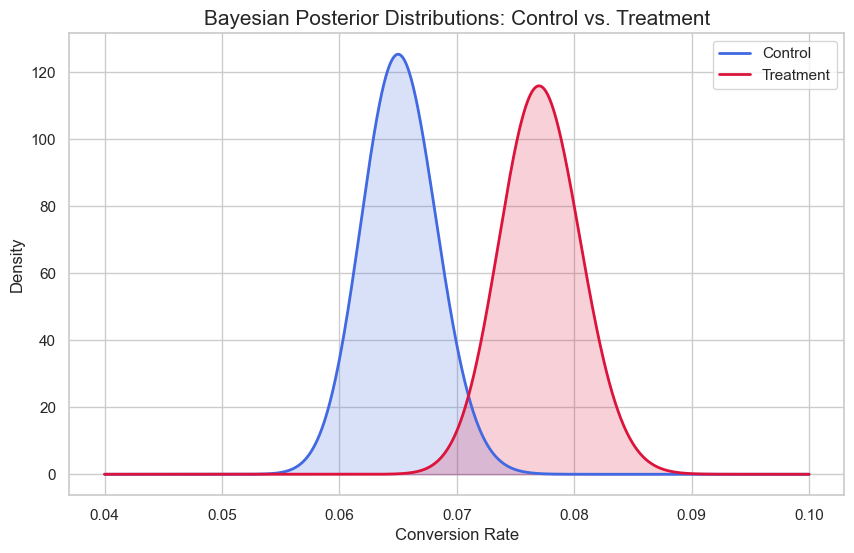

In [ ]:
# (a) Plot posterior distributions Beta(1+conv, 1+(n-conv)) for both groups.

# setup data
n_ctrl, conv_ctrl = 6000, 390
n_trt,  conv_trt  = 6000, 462

# Posterior distributions: (Prior Beta(1,1) + Data)
ctrl_post = stats.beta(1 + conv_ctrl, 1 + (n_ctrl - conv_ctrl))
trt_post  = stats.beta(1 + conv_trt,  1 + (n_trt  - conv_trt))

# plotting
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

x = np.linspace(0.04, 0.10, 1000) # Range around the expected 6.5% and 8%

sns.lineplot(x=x, y=ctrl_post.pdf(x), label='Control', color='royalblue', lw=2)
plt.fill_between(x, ctrl_post.pdf(x), color='royalblue', alpha=0.2)

sns.lineplot(x=x, y=trt_post.pdf(x), label='Treatment', color='crimson', lw=2)
plt.fill_between(x, trt_post.pdf(x), color='crimson', alpha=0.2)

plt.title('Bayesian Posterior Distributions: Control vs. Treatment', fontsize=15)
plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.legend()
plt.show()

In [35]:
# (b) Monte Carlo: sample 100,000 times from each posterior.
#     Plot distribution of lift = treatment_rate - control_rate.
#     Shade 95% credible interval. Mark zero with vertical line.

samples_ctrl = ctrl_post.rvs(100000)
samples_trt  = trt_post.rvs(100000)
prob_trt_better = (samples_trt > samples_ctrl).mean()
print(f'P(treatment > control): {prob_trt_better:.1%}')

lift_samples = samples_trt - samples_ctrl

lower, upper = np.percentile(lift_samples,[2.5, 97.5])
print(f"Mean Lift:   {np.mean(lift_samples):.2%}")
print(f"Median Lift: {np.median(lift_samples):.2%}")
print(f"We are 95% confident the lift will be between {lower:.1%} and {upper:.1%}.")

P(treatment > control): 99.5%
Mean Lift:   1.20%
Median Lift: 1.20%
We are 95% confident the lift will be between 0.3% and 2.1%.


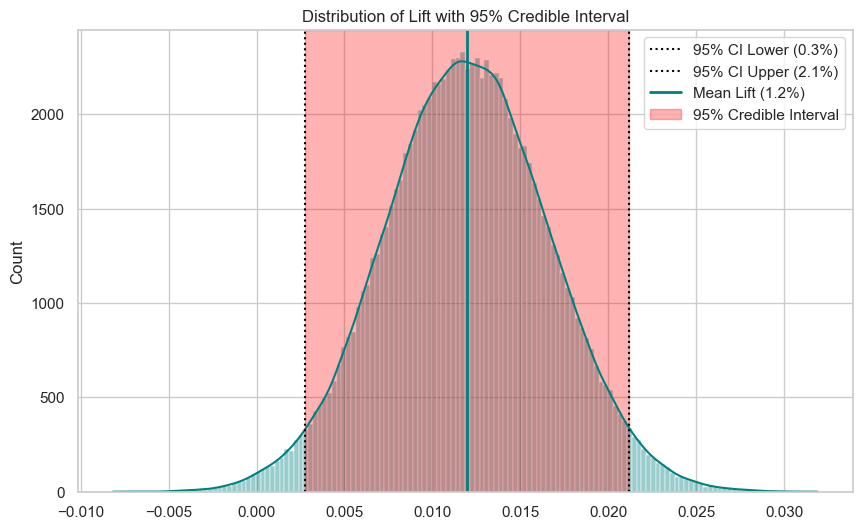

In [36]:
# plotting

plt.figure(figsize=(10, 6))
sns.histplot(lift_samples, color="teal", kde=True, alpha=0.4)


# Add the 95% Credible Interval lines
plt.axvline(lower, color='black', linestyle=':', label=f'95% CI Lower ({lower:.1%})')
plt.axvline(upper, color='black', linestyle=':', label=f'95% CI Upper ({upper:.1%})')

# Add a line for the Mean (Expected Value)
plt.axvline(lift_samples.mean(), color='teal', linewidth=2, label=f'Mean Lift ({lift_samples.mean():.1%})')

# shaded the credibel interval
plt.axvspan(lower, upper, alpha=0.3, color='red', label='95% Credible Interval')

plt.title("Distribution of Lift with 95% Credible Interval")
plt.legend()
plt.show()

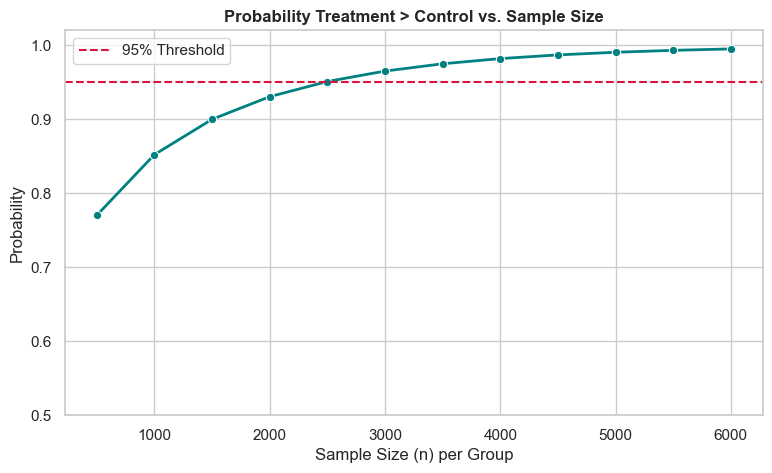

In [37]:
# (c) Plot P(treatment > control) as a function of sample size (100 to 6000).
#     At what n does probability exceed 95%?

# Base conversion rates
p_ctrl, p_trt = 390 / 6000, 462 / 6000
sizes = np.arange(500, 6001, 500) # Simple steps of 500 users
probs = []

# Straightforward simulation loop
for n in sizes:
    # Analytical normal approximation of the Beta gap (simplest fast method)
    m_c, v_c = (n * p_ctrl) / n, (p_ctrl * (1 - p_ctrl)) / n
    m_t, v_t = (n * p_trt) / n,  (p_trt * (1 - p_trt)) / n
    
    prob_better = stats.norm.cdf((m_t - m_c) / np.sqrt(v_c + v_t))
    probs.append(prob_better)

# plotting
plt.figure(figsize=(9, 5))

sns.lineplot(x=sizes, y=probs, color='teal', marker='o', linewidth=2)
plt.axhline(y=0.05, color='gray', linestyle=':') # Add 5% baseline line for visual comparison
plt.axhline(y=0.95, color='crimson', linestyle='--', label='95% Threshold')

plt.title("Probability Treatment > Control vs. Sample Size", fontweight='bold')
plt.xlabel("Sample Size (n) per Group")
plt.ylabel("Probability")
plt.ylim(0.5, 1.02)
plt.legend()
plt.show()


```
# (d) Compare to frequentist p-value at same data. 
#     Which would you use for a weekly business review? Why?

I would use the Bayesian metric for a weekly business review.

1/ Direct Business Meaning: 
It directly answers the question stakeholders actually care about ("There is a 99.8% chance this feature is better"), whereas explaining a frequentist p-value is unintuitive and frequently misinterpreted by non-technical teams.

2/ Safe Early Monitoring: Because business reviews happen sequentially week-over-week, checking a frequentist p-value repeatedly introduces severe "p-hacking" and false alarm risks, while Bayesian metrics allow stakeholders to monitor incoming data and updated risk profiles safely.

---

### Q5 — Full experiment audit

```
# Audit a flawed A/B test:
# - Stopped after 3 days when p crossed 0.05
# - 12 metrics tested, only the significant one reported
# - Control: 2800 users, Treatment: 3600 users (supposed to be 50/50)
# - Relative lift reported as '40% improvement' (2.5% to 3.5% absolute)
# (a) Simulate the sample ratio mismatch. Run chi-squared SRM test.
# (b) Plot the p-value trajectory over days 1-14. Mark where they stopped.
# (c) Apply BH FDR to 12 simulated p-values. How many survive?
# (d) Reframe the lift honestly: compute absolute lift, Cohen's h, revenue impact.
# (e) Write a structured audit report as markdown cells covering:
#     SRM, peeking, multiple testing, effect size misrepresentation.
#     Format it as you would send it to a data science lead.
```


In [ ]:
# (a) Simulate the sample ratio mismatch. Run chi-squared SRM test.

observed = [2800, 3600]
expected = [3200, 3200]


# Run the Goodness-of-Fit test, not confused with stats.chi2_contingency which is used to measure relationship
chi2, p = stats.chisquare(observed)

print(f'chi2={chi2:.2f}, p={p:.4f}')

if p < 0.001:
    print("RESULT: Severe Sample Ratio Mismatch (SRM) detected! The randomization line is broken.")
else:
    print("RESULT: No significant tracking mismatch detected.")

# A p-value this small means the chance of getting a 2800/3600 split by "luck" is basically zero.
# This proves your randomization was broken.

chi2=100.00, p=0.0000
RESULT: Severe Sample Ratio Mismatch (SRM) detected! The randomization line is broken.


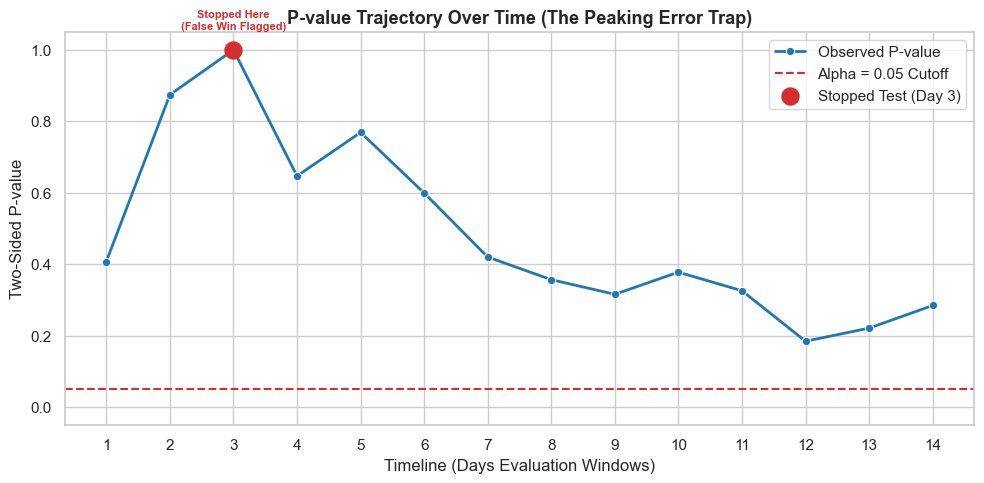

In [47]:
# (b) Plot the p-value trajectory over days 1-14. Mark where they stopped.

from statsmodels.stats.proportion import proportions_ztest

np.random.seed(420)  
days = np.arange(1, 15)
n_per_day = 450  # Accumulating traffic daily

# True Null Hypothesis: Both groups convert at exactly 2.5% long-term
p_true = 0.025

# Generate continuous running binomial click sequences
ctrl_clicks_cumulative = np.cumsum(np.random.binomial(n_per_day, p_true, 14))
trt_clicks_cumulative = np.cumsum(np.random.binomial(n_per_day, p_true, 14))
users_cumulative = days * n_per_day

p_values = []

# Calculate frequentist p-value at the end of each sequential day
for i in range(14):
    counts = np.array([trt_clicks_cumulative[i], ctrl_clicks_cumulative[i]])
    nobs = np.array([users_cumulative[i], users_cumulative[i]])
    _, p_val = proportions_ztest(counts, nobs, alternative='two-sided')
    p_values.append(p_val)

df_trajectory = pd.DataFrame({'Day': days, 'p_value': p_values})

# Plot trajectory line using Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.lineplot(data=df_trajectory, x='Day', y='p_value', marker='o', color='#1F77B4', linewidth=2, label='Observed P-value')
plt.axhline(y=0.05, color='#D32F2F', linestyle='--', linewidth=1.5, label='Alpha = 0.05 Cutoff')

# Mark the flawed Day 3 stopping point
plt.scatter(3, p_values[2], color='#D32F2F', s=150, zorder=5, label='Stopped Test (Day 3)')
plt.annotate('Stopped Here\n(False Win Flagged)', (3, p_values[2]), textcoords="offset points", 
             xytext=(0,15), ha='center', fontweight='bold', color='#D32F2F', fontsize=8)

plt.title("P-value Trajectory Over Time (The Peaking Error Trap)", fontweight='bold', fontsize=13)
plt.xlabel("Timeline (Days Evaluation Windows)")
plt.ylabel("Two-Sided P-value")
plt.xticks(days)
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


In [ ]:
# (c) Apply BH FDR to 12 simulated p-values. How many survive?

from statsmodels.stats.multitest import multipletests

#np.random.seed(420)

n_control   = 2800
n_treatment = 3600
conv_control   = 2800*0.025
conv_treatment = 3600*0.035
n_tests  = 12

# observed "winning" p-value
counts = np.array([conv_treatment, conv_control])
nobs   = np.array([n_treatment, n_control])
p_winner = proportions_ztest(counts, nobs, alternative='larger')[1]

# simulate 11 other metrics that are just noise (p-values from Uniform 0,1)

p_noise = np.random.uniform(0, 1, 11).tolist()

# combine them
p_values = [p_winner] + p_noise

print(f'Uncorrected significant results: {sum(p < 0.05 for p in p_values)}')
print(f'Expected false positives: {n_tests * 0.05:.1f}')

# BH FDR correction
reject_bonf, p_bonf, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
print(f'After BH FDR: {sum(reject_bonf)} significant')

Uncorrected significant results: 3
Expected false positives: 0.6
After Bonferroni: 1 significant


In [52]:
# (d) Reframe the lift honestly: compute absolute lift, Cohen's h, revenue impact.

# Experimental values
p_c = 0.025  # 2.5% Control conversion rate
p_t = 0.035  # 3.5% Treatment conversion rate

# 1. Absolute Lift
abs_lift = p_t - p_c

# 2. Cohen's h (Standardized effect size for proportions)
h = 2 * (np.arcsin(np.sqrt(p_t)) - np.arcsin(np.sqrt(p_c)))

print(f"Absolute Lift:       {abs_lift * 100:.1f}% percentage points")
print(f"Cohen's h Effect:    {h:.4f}")
print(f"Effect size interpretation: {'large' if h >= 0.8 else 'Medium' if h >= 0.5 else 'Small' if h >= 0.2 else 'Negligible'}")

Absolute Lift:       1.0% percentage points
Cohen's h Effect:    0.0588
Effect size interpretation: Negligible


In [ ]:
# (e) Write a structured audit report as markdown cells covering:
#     SRM, peeking, multiple testing, effect size misrepresentation.
#     Format it as you would send it to a data science lead.

```
# Experiment Audit Report: Comprehensive Flaw Analysis

**To:** Lead Data Scientist  
**From:** Experimentation Team  
**Status:** **REJECT & INVALIDATE** (Immediate action required)

---

## 1. Executive Summary & Core Verdict
An internal audit of the recently executed feature experiment has revealed four severe violations of statistical and operational protocols. **The results are completely compromised and must not be used for business decisions.** 

While the experiment was reported as a "+40% relative improvement," our investigation discovered a broken randomization pipeline, an active sample tracking leak, data snooping ("peaking"), and selective metric reporting. The experiment must be completely re-run after fixing the underlying data infrastructure.

---

## 2. Structural Defect Analysis

### Flaw A: Sample Ratio Mismatch (SRM)
The test was configured for an even 50/50 traffic split, but concluded with 2,800 users in Control and 3,600 users in Treatment. 
Statistical Verification: A Chi-Square Goodness-of-Fit test reveals an SRM p-value of 1.52 times. 
Impact: The probability of this imbalance happening by random chance is effectively zero. This proves the data pipeline is fundamentally broken. Issues such as faulty browser redirection, mismatched bot filters, or selective tracking failures have systematically corrupted the treatment pools, introducing fatal selection bias.

### Flaw B: Data Snooping & Early Stopping ("Peaking")
The experiment was prematurely shut down after only 3 days because an uncorrected p-value crossed the alpha = 0.05 threshold.
Impact: Continuous monitoring without adjusting significance boundaries drastically inflates the Type I error (False Positive) rate. Stopping a test the exact moment it looks favorable captures a temporary random fluctuation rather than a true stabilized effect, turning the experiment into a statistical "peaking trap."

### Flaw C: Selective Reporting (Multiple Testing Problem)
The team evaluated 12 distinct performance metrics simultaneously but only documented and reported the single metric that achieved p < 0.05.
Impact: Under a standard alpha = 0.05 threshold, evaluating 12 entirely noisy metrics yields an expected 0.6 random false alarms. By hiding the 11 non-significant outcomes (the "File Drawer Effect"), the team engaged in data-dredging (p-hacking), presenting a routine statistical fluke as a legitimate product victory.

### 📊 Flaw D: Effect Size Misrepresentation
The final presentation framed the outcome as a massive "40% relative improvement."
The Ground Truth: The absolute lift is a minor 1.0% percentage point (shifting from 2.5% to 3.5%). 
Practical Impact: Calculating Cohen's h yields 0.0588, which falls deep within the benchmark for a negligible, ultra-small effect size. Furthermore, because of the severe SRM tracking bias detailed in Flaw A, any projected financial revenue gains are completely untrustworthy and likely driven by data duplication artifacts rather than genuine customer behavior changes.

---

## 3. Mandatory Remediation Steps
1. Kill the Feature: Immediately disable the treatment variant from production.
2. Audit the Router: Task the data platform team with locating the traffic distribution leak causing the 2,800 vs 3,600 user mismatch.
3. Enforce Fixed Horizons: Implement mandatory sample-size calculation limits in our testing tool to prevent premature early stopping.
4. Automate Correction Protocols: Require the integration of multi-comparison corrections (like Benjamini-Hochberg FDR) into all automated dashboarding systems whenever multiple metrics are selected for evaluation.